
**RCNN Notebook**

Replace Markdown cell 0 with:

```markdown
# Faster R-CNN ResNet50-FPN V2 Training for BDD100K

This notebook independently trains and evaluates a two-stage Faster R-CNN detector for the same six BDD100K road classes. It combines COCO transfer learning, Feature Pyramid Networks, rare-class sampling, staged backbone fine-tuning, validation-based checkpoint selection, and confidence calibration.

At the balanced threshold, the final model achieved 73.46% test precision, 51.19% recall, 60.34% F1, 46.77% mAP50, and 26.18% mAP50:95. At the stricter threshold, precision increased to 81.75% while recall decreased to 46.40%.

## Architecture And Evaluation

Faster R-CNN is a two-stage detector. First, its Region Proposal Network identifies image areas that may contain objects. Second, the ROI prediction head classifies each proposal and improves its bounding box. ResNet50 extracts visual features, while the Feature Pyramid Network helps detect objects at multiple sizes.

Performance is measured with precision, recall, F1, mAP50, and mAP50:95. These metrics include false positives and missed objects, making them more informative than a single classification-style accuracy value.

In [1]:
from __future__ import annotations

import json
import math
import random
import sys
import time
from dataclasses import asdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.nn.utils import clip_grad_norm_
from torch.utils.data import DataLoader, Subset
from torchvision.utils import draw_bounding_boxes

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from road_detection.constants import PROJECT_CLASSES
from road_detection.rcnn_dataset import (
    RareClassBalancedSampler,
    YoloDetectionDataset,
    collate_fn,
)
from road_detection.rcnn_metrics import (
    evaluate_operating_points,
    evaluate_predictions,
    tune_score_threshold,
)
from road_detection.rcnn_model import (
    FAST_ACCURATE_RCNN_CONFIG,
    build_faster_rcnn,
    load_faster_rcnn_checkpoint,
)

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("Torchvision:", __import__("torchvision").__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

EXPECTED_VENV = Path(r"C:\tf214_hw2\Scripts\python.exe")
if EXPECTED_VENV.exists() and Path(sys.executable).resolve() != EXPECTED_VENV.resolve():
    raise RuntimeError("Select the Jupyter kernel 'Python (tf214_hw2)' before training.")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision("high")

Python: c:\tf214_hw2\Scripts\python.exe
PyTorch: 2.10.0+cu126
Torchvision: 0.25.0+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [2]:
RUN_MODE = "rtx3050_more_data"
BASE_RUN_TAG = "resnet50_fpn_v2_640_coverage_v3"
RESUME_TRAINING = True

PROFILES = {
    "smoke": {
        "pool_count": 128,
        "samples_per_epoch": 32,
        "proxy_val_count": 32,
        "epochs": 2,
        "head_epochs": 1,
        "deep_fine_start": 2,
        "warmup_steps": 8,
        "batch": 2,
        "min_size": 360,
        "max_size": 640,
        "final_eval_count": 64,
    },
    "rtx3050_more_data": {
        "pool_count": 32000,
        "samples_per_epoch": 640,
        "proxy_val_count": 128,
        "epochs": 32,
        "head_epochs": 3,
        "deep_fine_start": 27,
        "warmup_steps": 100,
        "batch": 4,
        "min_size": 360,
        "max_size": 640,
        "final_eval_count": 1500,
    },
    "overnight_accuracy": {
        "pool_count": 50000,
        "samples_per_epoch": 960,
        "proxy_val_count": 192,
        "epochs": 48,
        "head_epochs": 4,
        "deep_fine_start": 40,
        "warmup_steps": 150,
        "batch": 4,
        "min_size": 384,
        "max_size": 672,
        "final_eval_count": 2000,
    },
}
CFG = PROFILES[RUN_MODE]
if not 0 < CFG["head_epochs"] <= CFG["deep_fine_start"] <= CFG["epochs"]:
    raise ValueError("Training-stage boundaries must be ordered within the epoch count.")
if not 0 < CFG["samples_per_epoch"] <= CFG["pool_count"]:
    raise ValueError("samples_per_epoch must not exceed the candidate pool.")
RUN_TAG = f"{BASE_RUN_TAG}_{RUN_MODE}"
if RUN_MODE != "smoke" and not torch.cuda.is_available():
    raise RuntimeError("The real Faster R-CNN profiles require CUDA-enabled PyTorch.")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_ROOT = PROJECT_ROOT / "data" / "bdd100k_yolo"
RUN_DIR = PROJECT_ROOT / "runs" / "notebooks" / "rcnn_accuracy" / RUN_TAG
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "rcnn_final"
RUN_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
BEST_PATH = RUN_DIR / "best.pth"
LAST_PATH = RUN_DIR / "last.pth"
FINAL_PATH = PROJECT_ROOT / "models" / "fasterrcnn_bdd100k_resnet50_best.pth"
FINAL_PATH.parent.mkdir(parents=True, exist_ok=True)

if not (DATA_ROOT / "images" / "train").exists():
    raise FileNotFoundError(f"Converted BDD100K data not found at {DATA_ROOT}")
print(pd.Series(CFG, name=RUN_MODE))

pool_count           32000
samples_per_epoch      640
proxy_val_count        128
epochs                  32
head_epochs              3
deep_fine_start         27
warmup_steps           100
batch                    4
min_size               360
max_size               640
final_eval_count      1500
Name: rtx3050_more_data, dtype: int64


In [3]:
train_dataset = YoloDetectionDataset(
    DATA_ROOT,
    "train",
    max_size=CFG["max_size"],
    augment=True,
    horizontal_flip_probability=0.5,
)
val_dataset = YoloDetectionDataset(
    DATA_ROOT,
    "val",
    max_size=CFG["max_size"],
    augment=False,
)

pool_rng = random.Random(SEED)
candidate_indices = pool_rng.sample(
    range(len(train_dataset)),
    min(CFG["pool_count"], len(train_dataset)),
)
train_sampler = RareClassBalancedSampler(
    train_dataset,
    num_samples=min(CFG["samples_per_epoch"], len(candidate_indices)),
    num_classes=len(PROJECT_CLASSES),
    seed=SEED,
    rarity_exponent=0.55,
    max_weight=4.0,
    small_object_class_ids=(3, 4, 5),
    small_object_area_threshold=0.0025,
    small_object_boost=0.85,
    candidate_indices=candidate_indices,
    cache_path=RUN_DIR / "candidate_stats.json",
    scan_workers=12,
)

# Weighted coverage orders prioritize rare/small-object scenes while preventing
# repeats until the complete candidate pool has been traversed.
_coverage_orders = {}

def coverage_epoch_indices(epoch):
    pool_size = len(candidate_indices)
    sample_count = min(CFG["samples_per_epoch"], pool_size)
    cursor = epoch * sample_count
    selected = []
    while len(selected) < sample_count:
        cycle, offset = divmod(cursor, pool_size)
        if cycle not in _coverage_orders:
            generator = torch.Generator().manual_seed(SEED + 10000 + cycle)
            positions = torch.multinomial(
                train_sampler.weights,
                pool_size,
                replacement=False,
                generator=generator,
            ).tolist()
            _coverage_orders[cycle] = [candidate_indices[position] for position in positions]
        take = min(sample_count - len(selected), pool_size - offset)
        selected.extend(_coverage_orders[cycle][offset:offset + take])
        cursor += take
    return selected
val_indices = random.Random(SEED + 1).sample(
    range(len(val_dataset)),
    min(CFG["proxy_val_count"], len(val_dataset)),
)
val_dataset.cache_samples(val_indices, workers=12)
proxy_val_loader = DataLoader(
    Subset(val_dataset, val_indices),
    batch_size=CFG["batch"],
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_fn,
)
print("Class image counts in candidate pool:")
display(
    pd.DataFrame(
        {
            "class": PROJECT_CLASSES,
            "images": train_sampler.class_image_counts.tolist(),
            "rarity_weight": train_sampler.class_weights.tolist(),
        }
    )
)
print("Candidate images containing small pedestrian/light/sign boxes:",
      sum(count > 0 for count in train_sampler.small_object_counts))

Class image counts in candidate pool:


,class,images,rarity_weight
0,car,31614.0,1.000000
1,bus,4184.0,3.041293
2,truck,8570.0,2.050191
3,pedestrian,10126.0,1.870436
4,traffic light,18008.0,1.362786
5,traffic sign,26129.0,1.110494


Candidate images containing small pedestrian/light/sign boxes: 28280


In [4]:
model = build_faster_rcnn(
    num_classes=len(PROJECT_CLASSES) + 1,
    variant="resnet50",
    min_size=CFG["min_size"],
    max_size=CFG["max_size"],
    trainable_backbone_layers=3,
    pretrained=True,
    class_names=PROJECT_CLASSES,
    transfer_coco_head=True,
    performance_config=FAST_ACCURATE_RCNN_CONFIG,
).to(DEVICE)
model = model.to(memory_format=torch.channels_last)

amp_enabled = DEVICE.type == "cuda"

def collect_predictions(model, loader, device):
    model.eval()
    predictions = []
    targets_cpu = []
    with torch.inference_mode():
        for images, targets in loader:
            images = [image.to(device, non_blocking=True) for image in images]
            with torch.autocast(
                device_type=device.type,
                dtype=torch.float16,
                enabled=device.type == "cuda",
            ):
                outputs = model(images)
            predictions.extend(
                {
                    "boxes": output["boxes"].detach().float().cpu(),
                    "labels": output["labels"].detach().cpu(),
                    "scores": output["scores"].detach().float().cpu(),
                }
                for output in outputs
            )
            targets_cpu.extend(
                {
                    "boxes": target["boxes"].detach().cpu(),
                    "labels": target["labels"].detach().cpu(),
                }
                for target in targets
            )
    return predictions, targets_cpu

def stage_for_epoch(epoch):
    if epoch < CFG["head_epochs"]:
        return "head"
    if epoch < CFG["deep_fine_start"]:
        return "fine"
    return "deep"

def set_training_stage(detector, stage):
    for parameter in detector.backbone.body.parameters():
        parameter.requires_grad = False
    trainable_layers = {
        "head": (),
        "fine": ("layer4",),
        "deep": ("layer3", "layer4"),
    }[stage]
    for layer_name in trainable_layers:
            for parameter in getattr(detector.backbone.body, layer_name).parameters():
                parameter.requires_grad = True
    for parameter in detector.backbone.fpn.parameters():
        parameter.requires_grad = True
    for module in (detector.rpn, detector.roi_heads):
        for parameter in module.parameters():
            parameter.requires_grad = True

def build_optimizer(detector, stage):
    set_training_stage(detector, stage)
    body_parameters = [
        parameter
        for parameter in detector.backbone.body.parameters()
        if parameter.requires_grad
    ]
    body_ids = {id(parameter) for parameter in body_parameters}
    head_parameters = [
        parameter
        for parameter in detector.parameters()
        if parameter.requires_grad and id(parameter) not in body_ids
    ]
    head_lr, body_lr = {
        "head": (1.8e-4, 0.0),
        "fine": (1.2e-4, 1.2e-5),
        "deep": (7.0e-5, 5.0e-6),
    }[stage]
    groups = [{"params": head_parameters, "lr": head_lr}]
    if body_parameters:
        groups.append({"params": body_parameters, "lr": body_lr})
    return torch.optim.AdamW(groups, weight_decay=0.0005)

def metric_score(metrics):
    return 0.55 * metrics.map50 + 0.30 * metrics.f1 + 0.15 * metrics.map50_95

def metric_row(metrics):
    return {
        "precision": metrics.precision,
        "recall": metrics.recall,
        "f1": metrics.f1,
        "map50": metrics.map50,
        "map50_95": metrics.map50_95,
        "score_threshold": metrics.score_threshold,
        "quality": metric_score(metrics),
    }

def checkpoint_payload(detector, epoch, metrics, best_score, stage, optimizer=None, history=None):
    payload = {
        "model": detector.state_dict(),
        "epoch": epoch,
        "classes": PROJECT_CLASSES,
        "variant": "resnet50",
        "min_size": CFG["min_size"],
        "max_size": CFG["max_size"],
        "performance_config": FAST_ACCURATE_RCNN_CONFIG.to_dict(),
        "training_profile": RUN_MODE,
        "candidate_pool_size": len(candidate_indices),
        "samples_per_epoch": CFG["samples_per_epoch"],
        "coverage_sampling": True,
        "score_threshold": metrics.score_threshold,
        "validation_metrics": metric_row(metrics),
        "best_score": best_score,
        "stage": stage,
        "history": history or [],
    }
    if optimizer is not None:
        payload["optimizer"] = optimizer.state_dict()
    return payload

## COCO Transfer Initialization

The model begins with visual features learned from COCO. Compatible classifier and box-regression weights are transferred for cars, buses, trucks, people, and traffic lights. The BDD100K traffic-sign class begins from COCO stop-sign features.

The initialized model is evaluated before optimization and saved as a zero-step fallback. Training only replaces it when a later checkpoint improves the held-out validation score.

In [5]:
start_epoch = 0
history = []
best_score = -math.inf
current_stage = stage_for_epoch(start_epoch)
optimizer = build_optimizer(model, current_stage)

if RESUME_TRAINING and LAST_PATH.exists():
    resume = torch.load(LAST_PATH, map_location=DEVICE, weights_only=False)
    model.load_state_dict(resume["model"])
    start_epoch = int(resume["epoch"]) + 1
    history = list(resume.get("history", []))
    best_score = float(resume.get("best_score", -math.inf))
    current_stage = stage_for_epoch(start_epoch)
    optimizer = build_optimizer(model, current_stage)
    if resume.get("stage") == current_stage and "optimizer" in resume:
        optimizer.load_state_dict(resume["optimizer"])
    print(f"Resumed at epoch {start_epoch + 1}; best score {best_score:.4f}")
else:
    baseline_predictions, baseline_targets = collect_predictions(
        model, proxy_val_loader, DEVICE
    )
    baseline_metrics = tune_score_threshold(
        baseline_predictions,
        baseline_targets,
        thresholds=np.arange(0.10, 0.81, 0.05).round(2).tolist(),
        class_names=PROJECT_CLASSES,
        compute_map=True,
    )
    best_score = metric_score(baseline_metrics)
    torch.save(
        checkpoint_payload(
            model, -1, baseline_metrics, best_score, "baseline", history=history
        ),
        BEST_PATH,
    )
    display(pd.DataFrame([{"stage": "COCO transfer baseline", **metric_row(baseline_metrics)}]))

,stage,precision,recall,f1,map50,map50_95,score_threshold,quality
0,COCO transfer baseline,0.67344,0.408631,0.508633,0.375079,0.203833,0.55,0.389458


## Timed Staged Fine-Tuning

Training uses 32 epochs with 640 images per epoch selected from a weighted 32,000-image pool. The first three epochs train the FPN, proposal network, and prediction heads while freezing the ResNet body. Epochs 4-27 add ResNet layer 4, and epochs 28-32 also add layer 3 at a smaller learning rate.

Images are resized between 360 and 640 px, and batch size 4 with AMP fits the RTX 3050's 4 GB memory. Selected images are preloaded into memory so storage access does not interrupt every training batch.

In [6]:
scaler = torch.amp.GradScaler("cuda", enabled=amp_enabled)

for epoch in range(start_epoch, CFG["epochs"]):
    requested_stage = stage_for_epoch(epoch)
    if requested_stage != current_stage:
        current_stage = requested_stage
        optimizer = build_optimizer(model, current_stage)

    # Smooth cosine decay without fragile scheduler state across stage changes.
    stage_bounds = {
        "head": (0, CFG["head_epochs"]),
        "fine": (CFG["head_epochs"], CFG["deep_fine_start"]),
        "deep": (CFG["deep_fine_start"], CFG["epochs"]),
    }
    stage_start, stage_end = stage_bounds[current_stage]
    progress = (epoch - stage_start) / max(1, stage_end - stage_start - 1)
    cosine_factor = 0.10 + 0.90 * 0.5 * (1.0 + math.cos(math.pi * progress))
    base_lrs = {
        "head": (1.8e-4,),
        "fine": (1.2e-4, 1.2e-5),
        "deep": (7.0e-5, 5.0e-6),
    }[current_stage]
    for group_index, group in enumerate(optimizer.param_groups):
        group["lr"] = base_lrs[group_index] * cosine_factor
    target_lrs = [group["lr"] for group in optimizer.param_groups]

    epoch_indices = coverage_epoch_indices(epoch)
    preload_start = time.perf_counter()
    train_dataset.cache_samples(epoch_indices, workers=12, clear=True)
    preload_seconds = time.perf_counter() - preload_start
    train_loader = DataLoader(
        train_dataset,
        batch_size=CFG["batch"],
        sampler=epoch_indices,
        num_workers=0,
        pin_memory=amp_enabled,
        collate_fn=collate_fn,
    )

    model.train()
    train_start = time.perf_counter()
    running_loss = 0.0
    batches = 0
    for batch_index, (images, targets) in enumerate(train_loader):
        if epoch == 0 and batch_index < CFG["warmup_steps"]:
            warmup = 0.10 + 0.90 * (batch_index + 1) / CFG["warmup_steps"]
            for group, target_lr in zip(optimizer.param_groups, target_lrs):
                group["lr"] = target_lr * warmup
        elif epoch == 0 and batch_index == CFG["warmup_steps"]:
            for group, target_lr in zip(optimizer.param_groups, target_lrs):
                group["lr"] = target_lr
        images = [image.to(DEVICE, non_blocking=True) for image in images]
        targets = [
            {key: value.to(DEVICE, non_blocking=True) for key, value in target.items()}
            for target in targets
        ]
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(
            device_type=DEVICE.type,
            dtype=torch.float16,
            enabled=amp_enabled,
        ):
            loss_dict = model(images, targets)
            loss = sum(loss_dict.values())
        if not torch.isfinite(loss):
            raise RuntimeError(f"Non-finite loss at epoch {epoch + 1}: {loss_dict}")
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        clip_grad_norm_(
            [parameter for parameter in model.parameters() if parameter.requires_grad],
            max_norm=10.0,
        )
        scaler.step(optimizer)
        scaler.update()
        running_loss += float(loss.detach())
        batches += 1

    if amp_enabled:
        torch.cuda.synchronize()
    train_seconds = time.perf_counter() - train_start
    val_start = time.perf_counter()
    predictions, targets = collect_predictions(model, proxy_val_loader, DEVICE)
    metrics = tune_score_threshold(
        predictions,
        targets,
        thresholds=np.arange(0.10, 0.81, 0.05).round(2).tolist(),
        class_names=PROJECT_CLASSES,
        compute_map=True,
    )
    val_seconds = time.perf_counter() - val_start
    score = metric_score(metrics)
    row = {
        "epoch": epoch + 1,
        "stage": current_stage,
        "loss": running_loss / max(1, batches),
        "preload_seconds": preload_seconds,
        "train_seconds": train_seconds,
        "val_seconds": val_seconds,
        "unique_pool_images_seen": min(
            (epoch + 1) * CFG["samples_per_epoch"], len(candidate_indices)
        ),
        **metric_row(metrics),
    }
    history.append(row)

    if score > best_score:
        best_score = score
        torch.save(
            checkpoint_payload(
                model,
                epoch,
                metrics,
                best_score,
                current_stage,
                history=history,
            ),
            BEST_PATH,
        )
        marker = " NEW BEST"
    else:
        marker = ""

    torch.save(
        checkpoint_payload(
            model,
            epoch,
            metrics,
            best_score,
            current_stage,
            optimizer=optimizer,
            history=history,
        ),
        LAST_PATH,
    )
    pd.DataFrame(history).to_csv(RUN_DIR / "history.csv", index=False)
    print(
        f"Epoch {epoch + 1:03d} | {current_stage:5s} | "
        f"loss {row['loss']:.3f} | F1 {metrics.f1:.3f} | "
        f"mAP50 {metrics.map50:.3f} | preload {preload_seconds:.1f}s | "
        f"train {train_seconds:.1f}s | val {val_seconds:.1f}s | "
        f"unique {row['unique_pool_images_seen']:,}{marker}"
    )

Epoch 001 | head  | loss 1.359 | F1 0.466 | mAP50 0.321 | preload 0.6s | train 1083.0s | val 30.2s | unique 640
Epoch 002 | head  | loss 1.091 | F1 0.495 | mAP50 0.360 | preload 7.7s | train 1172.6s | val 23.9s | unique 1,280
Epoch 003 | head  | loss 1.046 | F1 0.522 | mAP50 0.372 | preload 7.0s | train 1004.2s | val 21.0s | unique 1,920 NEW BEST
Epoch 004 | fine  | loss 1.094 | F1 0.518 | mAP50 0.376 | preload 2.8s | train 1049.4s | val 22.4s | unique 2,560 NEW BEST
Epoch 005 | fine  | loss 1.046 | F1 0.531 | mAP50 0.385 | preload 7.5s | train 1040.5s | val 24.4s | unique 3,200 NEW BEST
Epoch 006 | fine  | loss 1.049 | F1 0.530 | mAP50 0.393 | preload 7.0s | train 1040.7s | val 22.0s | unique 3,840 NEW BEST
Epoch 007 | fine  | loss 1.066 | F1 0.543 | mAP50 0.412 | preload 2.6s | train 1040.6s | val 22.2s | unique 4,480 NEW BEST
Epoch 008 | fine  | loss 1.024 | F1 0.565 | mAP50 0.413 | preload 5.7s | train 1043.0s | val 21.8s | unique 5,120 NEW BEST
Epoch 009 | fine  | loss 1.028 | F1 

,epoch,stage,loss,preload_seconds,train_seconds,val_seconds,unique_pool_images_seen,precision,recall,f1,map50,map50_95,score_threshold,quality
22,23,fine,0.912786,1.280676,1039.389733,21.058294,14720,0.731242,0.523558,0.610213,0.491034,0.269750,0.40,0.493595
23,24,fine,0.952052,1.231168,1041.106399,21.558703,15360,0.733013,0.536768,0.619725,0.491834,0.266474,0.40,0.496398
24,25,fine,0.919549,4.442714,1095.345255,31.002577,16000,0.714953,0.538970,0.614612,0.494358,0.263960,0.35,0.495875
25,26,fine,0.936307,2.704099,1078.262694,29.704361,16640,0.703851,0.547336,0.615804,0.493367,0.267138,0.35,0.496164
26,27,fine,0.927190,3.408293,1475.292779,29.217721,17280,0.742544,0.537208,0.623403,0.503194,0.268647,0.40,0.504075
27,28,deep,0.955324,4.719292,1168.225121,20.777884,17920,0.699052,0.519595,0.596110,0.475266,0.255589,0.40,0.478568
28,29,deep,0.929580,3.845093,1153.922936,21.364757,18560,0.684358,0.539410,0.603300,0.481261,0.263627,0.35,0.485228
29,30,deep,0.907754,3.869368,1154.678996,21.296569,19200,0.685855,0.550859,0.610989,0.501408,0.274643,0.35,0.500268
30,31,deep,0.915943,6.374614,1155.703350,23.312203,19840,0.707289,0.534126,0.608630,0.485708,0.267371,0.40,0.489834
31,32,deep,0.912894,10.063652,1273.169774,21.312528,20480,0.684211,0.555262,0.613029,0.496332,0.277196,0.35,0.498470


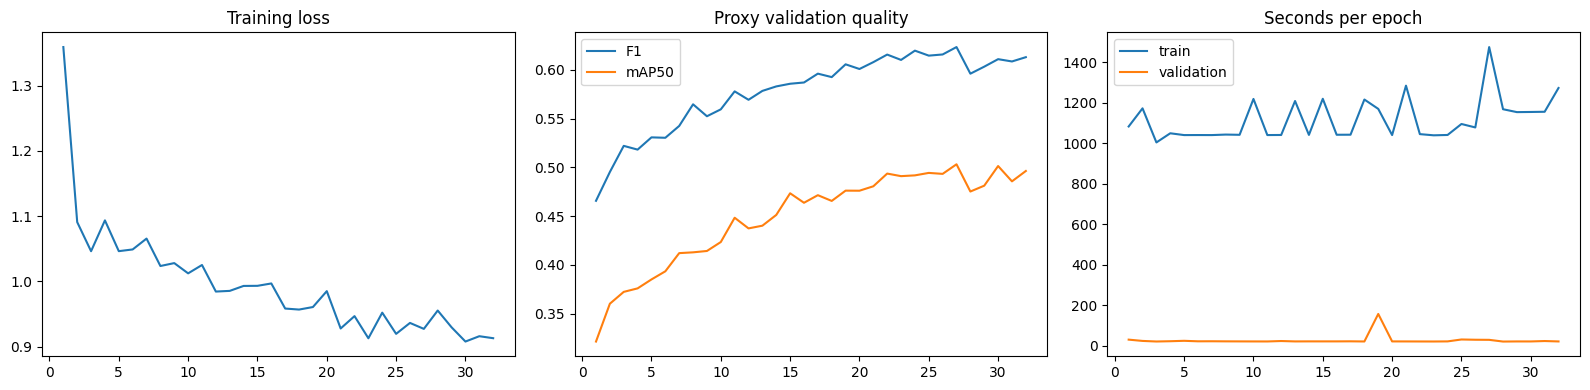

In [7]:
history_table = pd.DataFrame(history)
display(history_table.tail(10))
if len(history_table):
    figure, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].plot(history_table["epoch"], history_table["loss"])
    axes[0].set_title("Training loss")
    axes[1].plot(history_table["epoch"], history_table["f1"], label="F1")
    axes[1].plot(history_table["epoch"], history_table["map50"], label="mAP50")
    axes[1].legend()
    axes[1].set_title("Proxy validation quality")
    axes[2].plot(history_table["epoch"], history_table["train_seconds"], label="train")
    axes[2].plot(history_table["epoch"], history_table["val_seconds"], label="validation")
    axes[2].legend()
    axes[2].set_title("Seconds per epoch")
    plt.tight_layout()
    plt.show()

## Final Validation And Test Evaluation

The best training checkpoint is evaluated on 1,500 validation images and 1,500 held-out test images. Confidence thresholds are selected using validation data only and are then frozen before test evaluation.

The balanced threshold is 0.40. The stricter 0.55 threshold reached 81.06% validation precision and 81.75% test precision, with the expected reduction in recall.

In [8]:
best_model, class_names, best_metadata = load_faster_rcnn_checkpoint(BEST_PATH, DEVICE)
best_model = best_model.to(memory_format=torch.channels_last)

def make_eval_loader(split, count, seed):
    dataset = YoloDetectionDataset(
        DATA_ROOT,
        split,
        max_size=CFG["max_size"],
        augment=False,
    )
    indices = random.Random(seed).sample(range(len(dataset)), min(count, len(dataset)))
    dataset.cache_samples(indices, workers=12)
    loader = DataLoader(
        Subset(dataset, indices),
        batch_size=CFG["batch"],
        shuffle=False,
        num_workers=0,
        pin_memory=amp_enabled,
        collate_fn=collate_fn,
    )
    return dataset, indices, loader

final_val_dataset, final_val_indices, final_val_loader = make_eval_loader(
    "val", CFG["final_eval_count"], SEED + 20
)
final_test_dataset, final_test_indices, final_test_loader = make_eval_loader(
    "test", CFG["final_eval_count"], SEED + 21
)

val_predictions, val_targets = collect_predictions(best_model, final_val_loader, DEVICE)
balanced_metrics = tune_score_threshold(
    val_predictions,
    val_targets,
    thresholds=np.arange(0.10, 0.91, 0.05).round(2).tolist(),
    class_names=PROJECT_CLASSES,
    compute_map=True,
)
operating_points = evaluate_operating_points(
    val_predictions,
    val_targets,
    thresholds=np.arange(0.40, 0.96, 0.05).round(2).tolist(),
    class_names=PROJECT_CLASSES,
)
strict_candidates = [
    point for point in operating_points
    if point.precision >= 0.80 and point.true_positives > 0
]
high_precision_metrics = (
    max(strict_candidates, key=lambda point: (point.recall, point.f1))
    if strict_candidates
    else max(operating_points, key=lambda point: point.precision)
)

test_predictions, test_targets = collect_predictions(best_model, final_test_loader, DEVICE)
test_balanced = evaluate_predictions(
    test_predictions,
    test_targets,
    score_threshold=balanced_metrics.score_threshold,
    class_names=PROJECT_CLASSES,
)
test_high_precision = evaluate_predictions(
    test_predictions,
    test_targets,
    score_threshold=high_precision_metrics.score_threshold,
    class_names=PROJECT_CLASSES,
)

final_rows = [
    {"split": "validation", "profile": "balanced", **metric_row(balanced_metrics)},
    {"split": "validation", "profile": "high_precision_80", **metric_row(high_precision_metrics)},
    {"split": "test", "profile": "balanced", **metric_row(test_balanced)},
    {"split": "test", "profile": "high_precision_80", **metric_row(test_high_precision)},
]
final_table = pd.DataFrame(final_rows)
display(final_table)
final_table.to_csv(OUTPUT_DIR / "final_metrics.csv", index=False)

per_class_table = pd.DataFrame(balanced_metrics.per_class).T
per_class_table.index.name = "class"
display(per_class_table)
per_class_table.to_csv(OUTPUT_DIR / "validation_per_class.csv")

,split,profile,precision,recall,f1,map50,map50_95,score_threshold,quality
0,validation,balanced,0.730012,0.520394,0.607633,0.480028,0.265708,0.40,0.486162
1,validation,high_precision_80,0.810567,0.470045,0.595033,NaN,NaN,0.55,NaN
2,test,balanced,0.734587,0.511943,0.603382,0.467715,0.261828,0.40,0.477532
3,test,high_precision_80,0.817498,0.464028,0.592016,0.467715,0.261828,0.55,0.474122


,precision,recall,f1,ap50,map50_95,ground_truth
class,,,,,,
car,0.767090,0.608727,0.678795,0.652502,0.371924,15171.0
bus,0.651899,0.417004,0.508642,0.498885,0.356371,247.0
truck,0.622172,0.436508,0.513060,0.481775,0.325376,630.0
pedestrian,0.720069,0.403086,0.516847,0.421929,0.201229,2074.0
traffic light,0.655024,0.430266,0.519371,0.417957,0.140351,3879.0
traffic sign,0.668016,0.388998,0.491681,0.407121,0.198998,5090.0


In [9]:
# Save one deployment checkpoint with both measured operating points.
selected_checkpoint = torch.load(BEST_PATH, map_location="cpu", weights_only=False)
selected_checkpoint["score_threshold"] = balanced_metrics.score_threshold
selected_checkpoint["threshold_profiles"] = {
    "balanced": balanced_metrics.score_threshold,
    "high_precision_80": high_precision_metrics.score_threshold,
}
selected_checkpoint["final_validation_metrics"] = metric_row(balanced_metrics)
selected_checkpoint["final_test_metrics"] = metric_row(test_balanced)
selected_checkpoint["high_precision_validation"] = metric_row(high_precision_metrics)
torch.save(selected_checkpoint, FINAL_PATH)

deployment_summary = {
    "weights": str(FINAL_PATH),
    "balanced_threshold": balanced_metrics.score_threshold,
    "high_precision_threshold": high_precision_metrics.score_threshold,
    "high_precision_target_met": high_precision_metrics.precision >= 0.80,
    "validation": metric_row(balanced_metrics),
    "test": metric_row(test_balanced),
}
(OUTPUT_DIR / "deployment_summary.json").write_text(
    json.dumps(deployment_summary, indent=2),
    encoding="utf-8",
)
print("Deployment weights:", FINAL_PATH)
print("Balanced threshold:", balanced_metrics.score_threshold)
print(
    "High-precision threshold:",
    high_precision_metrics.score_threshold,
    "| measured validation precision:",
    f"{high_precision_metrics.precision:.3f}",
)

Deployment weights: C:\Users\vipra\OneDrive\Documents\GitHub\ECGR-5106-Intro-To-Deep-Learning\Final_Project\models\fasterrcnn_bdd100k_resnet50_best.pth
Balanced threshold: 0.4
High-precision threshold: 0.55 | measured validation precision: 0.811


Throughput: 6.65 images/s
Latency: 150.4 ms/image


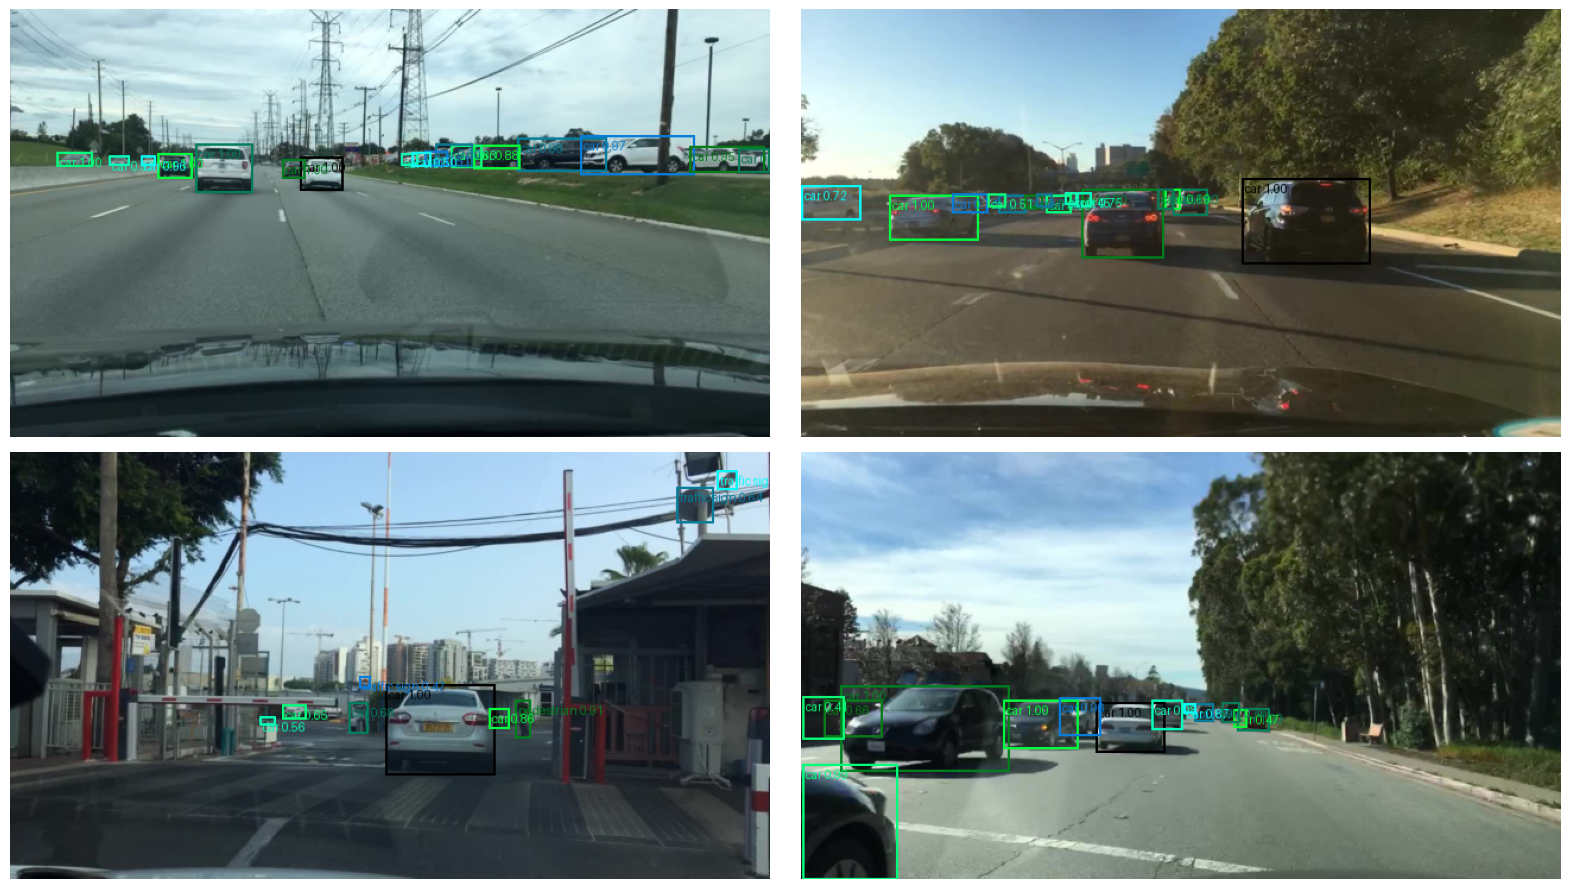

In [10]:
# Batch throughput after warm-up.
_ = collect_predictions(best_model, DataLoader(
    Subset(final_val_dataset, final_val_indices[:8]),
    batch_size=CFG["batch"],
    collate_fn=collate_fn,
), DEVICE)
if amp_enabled:
    torch.cuda.synchronize()
benchmark_loader = DataLoader(
    Subset(final_val_dataset, final_val_indices[:100]),
    batch_size=CFG["batch"],
    collate_fn=collate_fn,
)
started = time.perf_counter()
benchmark_predictions, benchmark_targets = collect_predictions(
    best_model, benchmark_loader, DEVICE
)
if amp_enabled:
    torch.cuda.synchronize()
elapsed = time.perf_counter() - started
print(f"Throughput: {len(benchmark_predictions) / elapsed:.2f} images/s")
print(f"Latency: {1000 * elapsed / len(benchmark_predictions):.1f} ms/image")

figure, axes = plt.subplots(2, 2, figsize=(16, 9))
for axis, dataset_index, prediction in zip(
    axes.flat, final_val_indices[:4], val_predictions[:4]
):
    image, _ = final_val_dataset[dataset_index]
    keep = prediction["scores"] >= balanced_metrics.score_threshold
    boxes = prediction["boxes"][keep]
    labels = [
        f"{PROJECT_CLASSES[int(label) - 1]} {float(score):.2f}"
        for label, score in zip(prediction["labels"][keep], prediction["scores"][keep])
    ]
    canvas = (image * 255).to(torch.uint8)
    drawn = draw_bounding_boxes(canvas, boxes, labels=labels, width=2)
    axis.imshow(drawn.permute(1, 2, 0))
    axis.axis("off")
plt.tight_layout()
plt.show()

## Real-Time Faster R-CNN Detection

```powershell
python -m road_detection.realtime_detect `
  --backend rcnn `
  --weights models\fasterrcnn_bdd100k_resnet50_best.pth `
  --source 0 `
  --device cuda